In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#dataset overview

In [36]:
# Load the Dataset
df=pd.read_csv("House_Pricing.csv")

In [37]:
# Display basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [38]:
# Display basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [39]:
# Check first few rows
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


#duplicate removal

In [40]:
# Check number of duplicate rows
df.duplicated().sum()

np.int64(0)

In [41]:
# View duplicate rows
df[df.duplicated()] # There are no duplicate rows in the dataset

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)


In [42]:
# check duplicate columns
duplicate_cols = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_cols.append(df.columns[j])

duplicate_cols

[]

In [43]:
# Shape check
df.shape

(21613, 21)

#handling missing values

In [44]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    '% Missing': missing_percentage
})

display(missing_info[missing_info['Missing Values'] > 0].sort_values(by='% Missing', ascending=False))

,Missing Values,% Missing
No of Times Visited,19489,90.172581
Flat Area (in Sqft),9,0.041642
Lot Area (in Sqft),9,0.041642
Sale Price,4,0.018507
No of Bathrooms,4,0.018507
Area of the House from Basement (in Sqft),3,0.013881
Zipcode,1,0.004627
Latitude,1,0.004627
Longitude,1,0.004627
Living Area after Renovation (in Sqft),1,0.004627


In [45]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Numerical columns: {list(numerical_cols)}")
print(f"Categorical columns: {list(categorical_cols)}")

Numerical columns: ['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']
Categorical columns: ['Date House was Sold', 'Waterfront View', 'No of Times Visited', 'Condition of the House']


#imputing missing values in numerical columns

data visualisation intereption

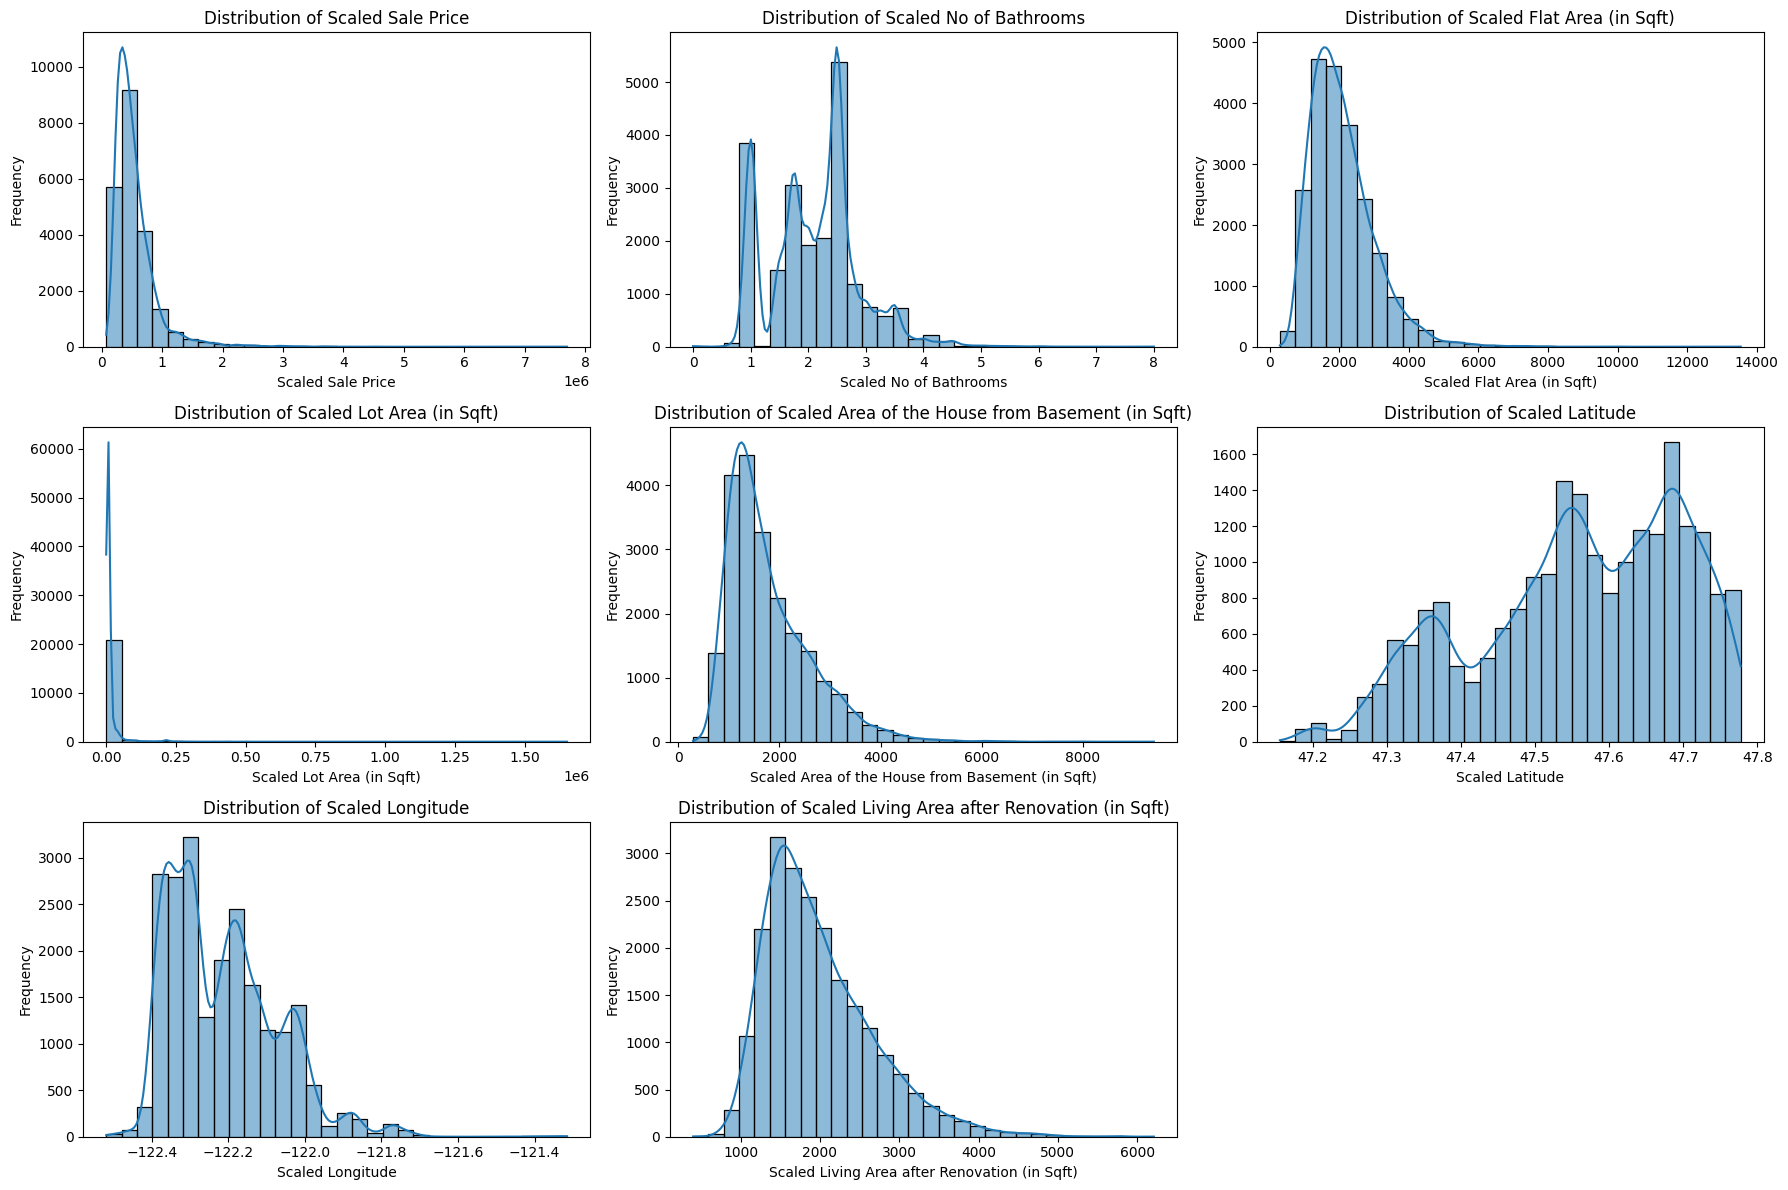

In [46]:
columns_to_plot = [
    'Sale Price',
    'No of Bathrooms',
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Latitude',
    'Longitude',
    'Living Area after Renovation (in Sqft)'
]


plt.figure(figsize=(18, 12))
for i, col in enumerate(columns_to_plot):
    plt.subplot(3, 3, i + 1) # Using a 3x3 grid, adjust as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of Scaled {col}')
    plt.xlabel(f'Scaled {col}')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [48]:
# Impute 'Sale Price' with the mean
df['Sale Price'] = df['Sale Price'].fillna(df['Sale Price'].mean())
print(f"'Sale Price' missing values imputed with mean: {df['Sale Price'].mean():.2f}")

'Sale Price' missing values imputed with mean: 540198.44


In [49]:
# Impute 'No of Bathrooms' with the median
df['No of Bathrooms'] = df['No of Bathrooms'].fillna(df['No of Bathrooms'].median())
print(f"'No of Bathrooms' missing values imputed with median: {df['No of Bathrooms'].median():.2f}")

'No of Bathrooms' missing values imputed with median: 2.25


In [50]:
# Impute 'Flat Area (in Sqft)' with the mean
df['Flat Area (in Sqft)'] = df['Flat Area (in Sqft)'].fillna(df['Flat Area (in Sqft)'].mean())
print(f"'Flat Area (in Sqft)' missing values imputed with mean: {df['Flat Area (in Sqft)'].mean():.2f}")

'Flat Area (in Sqft)' missing values imputed with mean: 2079.93


In [51]:
# Impute 'Lot Area (in Sqft)' with the mean
df['Lot Area (in Sqft)'] = df['Lot Area (in Sqft)'].fillna(df['Lot Area (in Sqft)'].mean())
print(f"'Lot Area (in Sqft)' missing values imputed with mean: {df['Lot Area (in Sqft)'].mean():.2f}")

'Lot Area (in Sqft)' missing values imputed with mean: 15107.76


In [53]:
# Impute 'Area of the House from Basement (in Sqft)' with the mean
df['Area of the House from Basement (in Sqft)'] = df['Area of the House from Basement (in Sqft)'].fillna(df['Area of the House from Basement (in Sqft)'].mean())
print(f"'Area of the House from Basement (in Sqft)' missing values imputed with mean: {df['Area of the House from Basement (in Sqft)'].mean():.2f}")

'Area of the House from Basement (in Sqft)' missing values imputed with mean: 1788.34


In [54]:
# Impute 'Zipcode' with the mode, as zipcodes are categorical in nature
df['Zipcode'] = df['Zipcode'].fillna(df['Zipcode'].mode()[0])
print(f"'Zipcode' missing values imputed with mode: {df['Zipcode'].mode()[0]:.0f}")

'Zipcode' missing values imputed with mode: 98103


In [55]:
# Impute 'Latitude' with the mean
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].mean())
print(f"'Latitude' missing values imputed with mean: {df['Latitude'].mean():.4f}")

'Latitude' missing values imputed with mean: 47.5600


In [56]:
# Impute 'Longitude' with the mean
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].mean())
print(f"'Longitude' missing values imputed with mean: {df['Longitude'].mean():.4f}")

'Longitude' missing values imputed with mean: -122.2139


In [58]:
# Impute 'Living Area after Renovation (in Sqft)' with the mean
df['Living Area after Renovation (in Sqft)'] = df['Living Area after Renovation (in Sqft)'].fillna(df['Living Area after Renovation (in Sqft)'].mean())
print(f"'Living Area after Renovation (in Sqft)' missing values imputed with mean: {df['Living Area after Renovation (in Sqft)'].mean():.2f}")

'Living Area after Renovation (in Sqft)' missing values imputed with mean: 1986.54


#imput missing values in categorical columns

In [59]:
print(df['No of Times Visited'].value_counts(dropna=False))

# Given the large number of NaN values and the potential for this to be a categorical feature,
# let's impute with the mode. It seems like 'None' or a similar representation might be appropriate.
# However, looking at the value_counts, the non-NaN values are strings like '4' or '2'.
# Let's convert it to a numerical type first if it's intended to be numerical.
# If it's truly categorical and 'NaN' means 'not visited', then 'None' is a good fill.
# From the info, it's an object type, suggesting it might be categorical, or a mixed type.
# Let's assume it represents 'number of times visited' and the `NaN` means 0 times.
# First, we need to convert the existing values to numeric, coercing errors.

df['No of Times Visited'] = pd.to_numeric(df['No of Times Visited'], errors='coerce')
# Now, fill the remaining NaNs (which include the original NaNs and any values that couldn't be converted)
# with 0, assuming NaN means 'not visited'.
df['No of Times Visited'] = df['No of Times Visited'].fillna(0)

print(f"'No of Times Visited' missing values imputed with 0 (representing 'not visited').")
print(df['No of Times Visited'].value_counts(dropna=False))

No of Times Visited
NaN       19489
Twice       963
Thrice      510
Once        332
Four        319
Name: count, dtype: int64
'No of Times Visited' missing values imputed with 0 (representing 'not visited').
No of Times Visited
0.0    21613
Name: count, dtype: int64


Check missing values

#final verification of missing values

In [60]:
final_missing_values = df.isnull().sum()
final_missing_percentage = (df.isnull().sum() / len(df)) * 100

final_missing_info = pd.DataFrame({
    'Missing Values': final_missing_values,
    '% Missing': final_missing_percentage
})

display(final_missing_info[final_missing_info['Missing Values'] > 0])

print("All missing values have been handled.")

,Missing Values,% Missing


All missing values have been handled.


#scaler numerical variables

In [61]:
from sklearn.preprocessing import StandardScaler

# 'numerical_cols' was defined earlier in the notebook. Ensuring it's up-to-date.
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Exclude 'ID' and 'Zipcode' from scaling
columns_to_scale = [col for col in numerical_cols if col not in ['ID', 'Zipcode']]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("Numerical columns have been scaled using StandardScaler.")
print("Displaying the first 5 rows of the scaled numerical columns:")
display(df[columns_to_scale].head())

Numerical columns have been scaled using StandardScaler.
Displaying the first 5 rows of the scaled numerical columns:


,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,-0.866480,-0.398737,-1.447640,-0.980024,-0.228345,-0.915427,0.0,-0.564013,-0.734799,-0.658681,0.544898,-0.210128,-0.352541,-0.306117,-0.943339,-0.260715
1,-0.005985,-0.398737,0.175628,0.533683,-0.189908,0.936506,0.0,-0.564013,0.460989,0.245141,0.681079,4.746678,1.161620,-0.746386,-0.432668,-0.187868
2,-0.980541,-1.473959,-1.447640,-1.426513,-0.123320,-0.915427,0.0,-1.468651,-1.230024,-0.658681,1.293892,-0.210128,1.283590,-0.135691,1.070164,-0.172375
3,0.173682,0.676485,1.149589,-0.130605,-0.244039,-0.915427,0.0,-0.564013,-0.891821,1.397515,0.204446,-0.210128,-0.283256,-1.271867,-0.914158,-0.284522
4,-0.082207,-0.398737,-0.149026,-0.435525,-0.169676,-0.915427,0.0,0.340626,-0.130865,-0.658681,-0.544548,-0.210128,0.409591,1.199316,-0.272172,-0.192849


#encoding categorical variables

In [63]:
df['Date House was Sold'] = pd.to_datetime(df['Date House was Sold'])
df['Sale_Year'] = df['Date House was Sold'].dt.year
df['Sale_Month'] = df['Date House was Sold'].dt.month
df['Sale_Day_of_Week'] = df['Date House was Sold'].dt.dayofweek

# Drop the original 'Date House was Sold' column
df.drop('Date House was Sold', axis=1, inplace=True)

print("Extracted year, month, and day of week from 'Date House was Sold' and dropped the original column.")
display(df[['Sale_Year', 'Sale_Month', 'Sale_Day_of_Week']].head())

Extracted year, month, and day of week from 'Date House was Sold' and dropped the original column.


,Sale_Year,Sale_Month,Sale_Day_of_Week
0,2017,10,5
1,2017,12,3
2,2016,2,0
3,2017,12,3
4,2016,2,0


In [64]:
df = pd.get_dummies(df, columns=['Waterfront View'], prefix='Waterfront', drop_first=True)

print("'Waterfront View' column one-hot encoded.")
display(df[['Waterfront_Yes']].head())

'Waterfront View' column one-hot encoded.


,Waterfront_Yes
0,False
1,False
2,False
3,False
4,False


In [65]:
from sklearn.preprocessing import LabelEncoder

print("Unique values in 'Condition of the House' before encoding:")
print(df['Condition of the House'].value_counts())

# Define the ordinal mapping based on common sense for house condition
condition_mapping = {
    'Fair': 0,
    'Good': 1,
    'Average': 2,
    'Bad': 3,
    'Excellent': 4
}

df['Condition of the House'] = df['Condition of the House'].map(condition_mapping)

print("'Condition of the House' column label encoded.")
display(df[['Condition of the House']].head())

Unique values in 'Condition of the House' before encoding:
Condition of the House
Fair         14031
Good          5679
Excellent     1701
Okay           172
Bad             30
Name: count, dtype: int64
'Condition of the House' column label encoded.


,Condition of the House
0,0.0
1,0.0
2,0.0
3,4.0
4,0.0


#outlier removal

In [66]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    initial_rows = df.shape[0]
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    removed_rows = initial_rows - df_filtered.shape[0]
    if removed_rows > 0:
        print(f"Removed {removed_rows} outliers from '{column}'.")
    return df_filtered

# Re-identifying numerical columns as the DataFrame structure might have changed slightly with encoding.
# Exclude 'ID' and 'Zipcode' from outlier removal, as they are identifiers/categorical.
current_numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
columns_for_outlier_removal = [col for col in current_numerical_cols if col not in ['ID', 'Zipcode', 'Sale_Year', 'Sale_Month', 'Sale_Day_of_Week', 'Condition of the House']]

initial_shape = df.shape
print(f"Initial DataFrame shape: {initial_shape}")

for col in columns_for_outlier_removal:
    df = remove_outliers_iqr(df, col)

final_shape = df.shape
print(f"Final DataFrame shape after outlier removal: {final_shape}")
print(f"Total rows removed: {initial_shape[0] - final_shape[0]}")

display(df.head())

Initial DataFrame shape: (21613, 23)
Removed 1159 outliers from 'Sale Price'.
Removed 482 outliers from 'No of Bedrooms'.
Removed 67 outliers from 'No of Bathrooms'.
Removed 264 outliers from 'Flat Area (in Sqft)'.
Removed 2057 outliers from 'Lot Area (in Sqft)'.
Removed 661 outliers from 'Overall Grade'.
Removed 442 outliers from 'Area of the House from Basement (in Sqft)'.
Removed 234 outliers from 'Basement Area (in Sqft)'.
Removed 579 outliers from 'Renovated Year'.
Removed 344 outliers from 'Longitude'.
Removed 140 outliers from 'Living Area after Renovation (in Sqft)'.
Removed 322 outliers from 'Lot Area after Renovation (in Sqft)'.
Final DataFrame shape after outlier removal: (14862, 23)
Total rows removed: 6751


,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Condition of the House,Overall Grade,...,Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year,Sale_Month,Sale_Day_of_Week,Waterfront_Yes
0,7129300520,-0.866480,-0.398737,-1.447640,-0.980024,-0.228345,-0.915427,0.0,0.0,-0.564013,...,-0.210128,98178.0,-0.352541,-0.306117,-0.943339,-0.260715,2017,10,5,False
2,5631500400,-0.980541,-1.473959,-1.447640,-1.426513,-0.123320,-0.915427,0.0,0.0,-1.468651,...,-0.210128,98028.0,1.283590,-0.135691,1.070164,-0.172375,2016,2,0,False
3,2487200875,0.173682,0.676485,1.149589,-0.130605,-0.244039,-0.915427,0.0,4.0,-0.564013,...,-0.210128,98136.0,-0.283256,-1.271867,-0.914158,-0.284522,2017,12,3,False
4,1954400510,-0.082207,-0.398737,-0.149026,-0.435525,-0.169676,-0.915427,0.0,0.0,0.340626,...,-0.210128,98074.0,0.409591,1.199316,-0.272172,-0.192849,2016,2,0,False
6,1321400060,-0.769569,-0.398737,0.175628,-0.397410,-0.200121,0.936506,0.0,0.0,-0.564013,...,-0.210128,98003.0,-1.806799,-0.803194,0.366897,-0.217900,2017,6,2,False


#train -test split

In [67]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Sale Price', axis=1)
y = df['Sale Price']

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset split into training and testing sets.
X_train shape: (11889, 22)
X_test shape: (2973, 22)
y_train shape: (11889,)
y_test shape: (2973,)
